In [1]:
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader


data = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [2]:
data

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [3]:
data['TotalCharges']

0         29.85
1        1889.5
2        108.15
3       1840.75
4        151.65
         ...   
7038     1990.5
7039     7362.9
7040     346.45
7041      306.6
7042     6844.5
Name: TotalCharges, Length: 7043, dtype: str

In [4]:
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce').fillna(0)

In [5]:
data['TotalCharges']

0         29.85
1       1889.50
2        108.15
3       1840.75
4        151.65
         ...   
7038    1990.50
7039    7362.90
7040     346.45
7041     306.60
7042    6844.50
Name: TotalCharges, Length: 7043, dtype: float64

In [6]:
data['Churn']

0        No
1        No
2       Yes
3        No
4       Yes
       ... 
7038     No
7039     No
7040     No
7041    Yes
7042     No
Name: Churn, Length: 7043, dtype: str

In [7]:
y = data['Churn'].map({'Yes': 1, 'No': 0})
X = data.drop(columns=['Churn', 'customerID'])

In [8]:
y

0       0
1       0
2       1
3       0
4       1
       ..
7038    0
7039    0
7040    0
7041    1
7042    0
Name: Churn, Length: 7043, dtype: int64

In [9]:
X

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60


In [10]:
X = pd.get_dummies(X, drop_first=True, dtype=float)

In [11]:
X

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,0,34,56.95,1889.50,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,0,2,53.85,108.15,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
3,0,45,42.30,1840.75,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,0,2,70.70,151.65,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,24,84.80,1990.50,1.0,1.0,1.0,1.0,0.0,1.0,...,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0
7039,0,72,103.20,7362.90,0.0,1.0,1.0,1.0,0.0,1.0,...,0.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0
7040,0,11,29.60,346.45,0.0,1.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
7041,1,4,74.40,306.60,1.0,1.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0


In [12]:
from sklearn.preprocessing import StandardScaler
import torch.nn as nn
import torch.optim as optim

class ChurnModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),    # Add a second hidden layer stepping down to 32
            nn.ReLU(),
            nn.Dropout(0.1),      # Slightly lower dropout on the deeper layer
            nn.Linear(32, 1),
            # nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x)


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=44, shuffle=True
)

# 2. Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
 
# 3. Convert all splits to PyTorch Tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32) 
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1)

In [14]:
y_train.values

array([0, 0, 0, ..., 0, 0, 1], shape=(5634,))

In [15]:
y_train.shape

(5634,)

In [16]:
y_train_tensor.shape

torch.Size([5634, 1])

In [17]:
X_train_tensor

tensor([[-0.4412, -0.9433, -1.3273,  ..., -0.5315,  1.4199, -0.5477],
        [-0.4412,  1.6200, -0.0025,  ..., -0.5315,  1.4199, -0.5477],
        [-0.4412, -1.2688, -0.3025,  ..., -0.5315, -0.7043,  1.8259],
        ...,
        [-0.4412,  1.2131,  1.3756,  ...,  1.8815, -0.7043, -0.5477],
        [-0.4412,  0.4808,  0.2058,  ..., -0.5315,  1.4199, -0.5477],
        [-0.4412, -1.2688, -1.4856,  ..., -0.5315, -0.7043,  1.8259]])

In [18]:
X_train_scaled

array([[-0.44119892, -0.94328209, -1.3273276 , ..., -0.53150247,
         1.41988026, -0.54768043],
       [-0.44119892,  1.61999733, -0.00253038, ..., -0.53150247,
         1.41988026, -0.54768043],
       [-0.44119892, -1.26877789, -0.30248447, ..., -0.53150247,
        -0.70428474,  1.82588229],
       ...,
       [-0.44119892,  1.21312758,  1.37559201, ...,  1.88145879,
        -0.70428474, -0.54768043],
       [-0.44119892,  0.48076203,  0.20577107, ..., -0.53150247,
         1.41988026, -0.54768043],
       [-0.44119892, -1.26877789, -1.4856367 , ..., -0.53150247,
        -0.70428474,  1.82588229]], shape=(5634, 30))

In [31]:
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

In [38]:
num_negatives = (y_train_tensor == 0).sum()
num_positives = (y_train_tensor == 1).sum()
pos_weight_value = num_negatives / num_positives

model = ChurnModel(input_dim=X_train_tensor.shape[1])
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_value)
optimizer = optim.Adam(model.parameters(), lr=0.01)

print("Starting Training...")
for epoch in range(10):
    epoch_loss = 0.0

    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()

        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * batch_X.size(0)

    total_epoch_loss = epoch_loss / len(train_dataset)

    if epoch % 10 == 0:
        print(f"Epoch {epoch:03d} | Average Loss: {total_epoch_loss:.4f}")

model.eval()
with torch.no_grad():
    test_logits = model(X_test_tensor)
    test_probs = torch.sigmoid(test_logits)
    predictions = (test_probs >= 0.5).float()

    correct = (predictions == y_test_tensor).sum().item()
    accuracy = correct / y_test_tensor.size(0)

print(f"\nNew Test Accuracy: {accuracy * 100:.2f}%")

Starting Training...
Epoch 000 | Average Loss: 0.7713

New Test Accuracy: 77.64%


--- New Classification Report ---
              precision    recall  f1-score   support

  Stayed (0)       0.87      0.79      0.83      1027
 Churned (1)       0.55      0.69      0.62       382

    accuracy                           0.77      1409
   macro avg       0.71      0.74      0.72      1409
weighted avg       0.79      0.77      0.77      1409



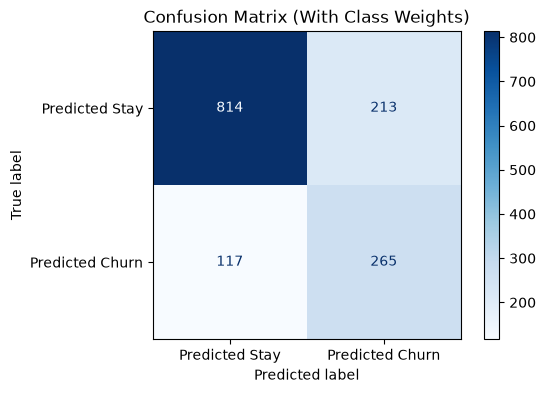

In [23]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

model.eval()
with torch.no_grad():
    raw_logits = model(X_test_tensor)
    
    probabilities = torch.sigmoid(raw_logits)
    
    predictions = (probabilities >= 0.5).float()
    
    y_true = y_test_tensor.cpu().numpy()
    y_pred = predictions.cpu().numpy()

print("--- New Classification Report ---")
print(classification_report(y_true, y_pred, target_names=['Stayed (0)', 'Churned (1)']))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Predicted Stay', 'Predicted Churn'])

fig, ax = plt.subplots(figsize=(6, 4))
disp.plot(ax=ax, cmap='Blues')
plt.title("Confusion Matrix (With Class Weights)")
plt.show()